In [3]:
import pandas as pd

# Replace 'your_file.csv' with the actual name of the file you scraped
df = pd.read_csv('gsearch_jobs_2023_q2.csv') 

# This shows the first 5 rows to make sure it loaded correctly
df.head()

,data_job_id,idx,title,company_name,job_location,via,description,extensions,job_id,thumbnail,...,commute_time,salary_pay,salary_rate,salary_avg,salary_min,salary_max,salary_hourly,salary_yearly,salary_standardized,description_tokens
0,3780,1693,Production Data Analyst 3899,OneSource Professional Search,United States,via WayUp,"Our client is an independent, financially soun...","['2 hours ago', 'Full-time', 'No degree mentio...",eyJqb2JfdGl0bGUiOiJQcm9kdWN0aW9uIERhdGEgQW5hbH...,https://encrypted-tbn0.gstatic.com/images?q=tb...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['excel']
1,3782,1695,Data Analyst,NYC Careers,"Manhattan, KS",via Emprego.pt,The New York City Housing Authority (NYCHA) is...,"['3 hours ago', 'Full-time']",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]
2,3785,1698,Senior Healthcare Data Analyst (Remote),The Lancet,United States,via Mendeley,• *Description**\n• *_Providence Health Plan c...,"['3 hours ago', 'Full-time', 'Health insurance']",eyJqb2JfdGl0bGUiOiJTZW5pb3IgSGVhbHRoY2FyZSBEYX...,https://encrypted-tbn0.gstatic.com/images?q=tb...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['tableau', 'power_bi', 'sql', 'vba']"
3,3786,1699,(USA) Senior Data Analyst - Tech,Walmart,"Bentonville, AR",via The Muse,Position Summary...\n\nWhat you'll do...\n\nAr...,"['3 hours ago', 'Full-time', 'Health insurance...",eyJqb2JfdGl0bGUiOiIoVVNBKSBTZW5pb3IgRGF0YSBBbm...,https://encrypted-tbn0.gstatic.com/images?q=tb...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['tableau', 'power_bi', 'python', 'sql']"
4,3789,1702,Staff Data Analyst - People Analytics Product ...,Walmart,"Bentonville, AR",via The Muse,Position Summary...\n\nWhat you'll do...\n\nAb...,"['3 hours ago', 'Full-time', 'Health insurance...",eyJqb2JfdGl0bGUiOiJTdGFmZiBEYXRhIEFuYWx5c3QgLS...,https://encrypted-tbn0.gstatic.com/images?q=tb...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['tableau', 'word', 'power_bi', 'scala', 'pyth..."


In [6]:
# 1. Standardize text to lowercase
df['description'] = df['description'].astype(str).str.lower()

keywords = ['python', 'sql', 'tableau', 'excel', 'power bi']

for skill in keywords:
    df[skill] = df['description'].apply(lambda x: 1 if skill in x else 0)

df[keywords].sum()

# 2. Extract Skills (The key part for your project)
keywords = ['python', 'sql', 'tableau', 'excel', 'power bi']

for skill in keywords:
    df[skill] = df['description'].apply(lambda x: 1 if skill in str(x) else 0)

# 3. Check your work - this will show the count of each skill
df[keywords].sum()

python      2057
sql         3739
tableau     2094
excel       3646
power bi    1380
dtype: int64

In [8]:
# 1. Select only the columns we actually need
# (Adjust these names if your print(df.columns) showed something different)
columns_to_keep = ['title', 'company_name', 'location', 'description', 'salary_standardized']
# 1. Select only the columns we actually need
# (Adjust these names if your print(df.columns) showed something different)
columns_to_keep = ['title', 'company_name', 'job_location', 'description', 'salary_standardized']
df_clean = df[columns_to_keep].copy()

# 2. Clean the description text (make it lowercase for easier searching)
df_clean['description'] = df_clean['description'].str.lower()

# 3. Define the skills you want to analyze
keywords = ['python', 'sql', 'tableau', 'excel', 'power bi', 'aws', 'azure']

# 4. The "Skill Matrix" - Creating 1s and 0s for each skill
for skill in keywords:
    # This creates a new column for each skill
    df_clean[skill] = df_clean['description'].apply(lambda x: 1 if skill in str(x) else 0)

# 5. Show the total count for each skill to see what's trending
print("Total job postings analyzed:", len(df_clean))
print("\nSkill Frequency:")
print(df_clean[keywords].sum().sort_values(ascending=False))

# 6. Save this as your 'Gold' dataset for the next stage (Charts)
df_clean.to_csv('cleaned_jobs_final.csv', index=False)

# 2. Clean the description text (make it lowercase for easier searching)
df_clean['description'] = df_clean['description'].str.lower()

# 3. Define the skills you want to analyze
keywords = ['python', 'sql', 'tableau', 'excel', 'power bi', 'aws', 'azure']

# 4. The "Skill Matrix" - Creating 1s and 0s for each skill
for skill in keywords:
    # This creates a new column for each skill
    df_clean[skill] = df_clean['description'].apply(lambda x: 1 if skill in str(x) else 0)

# 5. Show the total count for each skill to see what's trending
print("Total job postings analyzed:", len(df_clean))
print("\nSkill Frequency:")
print(df_clean[keywords].sum().sort_values(ascending=False))

# 6. Save this as your 'Gold' dataset for the next stage (Charts)
df_clean.to_csv('cleaned_jobs_final.csv', index=False)

Total job postings analyzed: 7212

Skill Frequency:
sql         3739
excel       3646
tableau     2094
python      2057
power bi    1380
aws          873
azure        406
dtype: int64
Total job postings analyzed: 7212

Skill Frequency:
sql         3739
excel       3646
tableau     2094
python      2057
power bi    1380
aws          873
azure        406
dtype: int64


C:\Users\ELCOT\AppData\Local\Temp\ipykernel_11696\1383545947.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=skill_perc.values, y=skill_perc.index, palette='viridis')


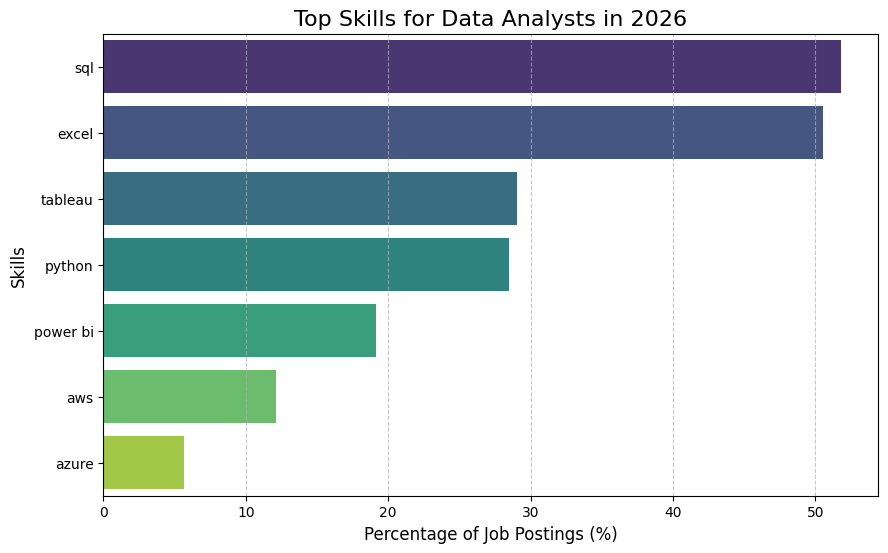

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the percentage of jobs requiring each skill
skill_counts = df_clean[keywords].sum().sort_values(ascending=False)
skill_perc = (skill_counts / len(df_clean)) * 100

# 2. Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(x=skill_perc.values, y=skill_perc.index, palette='viridis')

# 3. Add labels and styling
plt.title('Top Skills for Data Analysts in 2026', fontsize=16)
plt.xlabel('Percentage of Job Postings (%)', fontsize=12)
plt.ylabel('Skills', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# 4. Show the chart
plt.show()

<Figure size 1000x600 with 0 Axes>

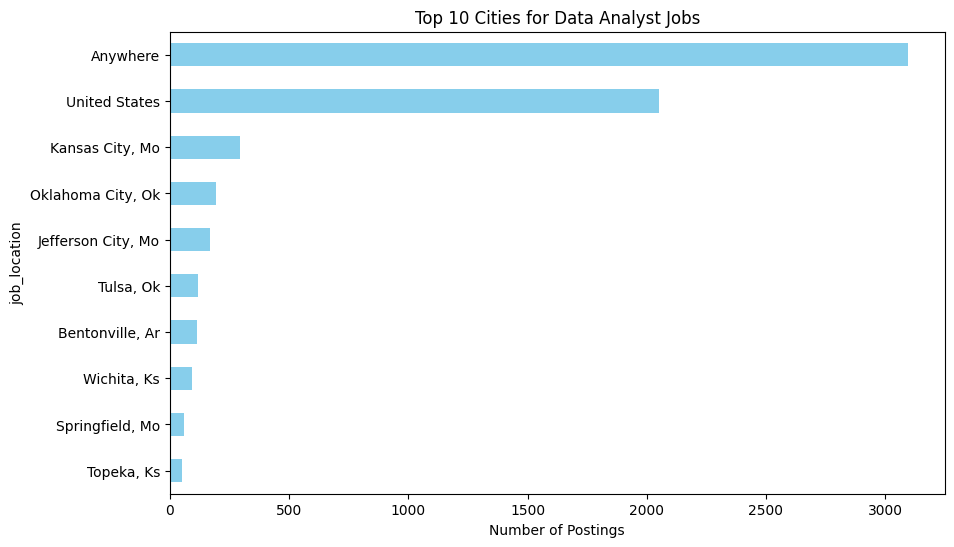

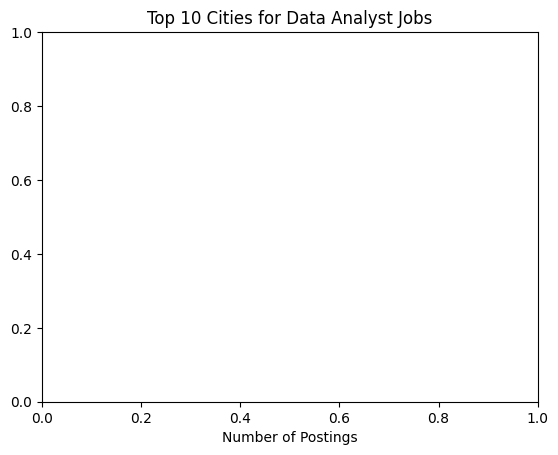

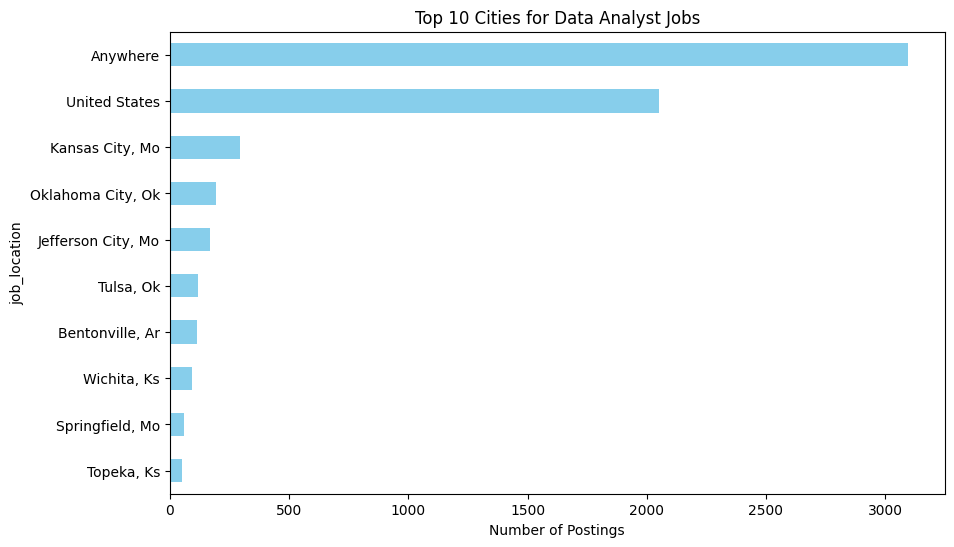

In [15]:
# Top 10 cities for Data Analyst jobs
plt.figure(figsize=(10, 6))
# Top 10 cities for Data Analyst jobs
plt.figure(figsize=(10, 6))
df_clean['job_location'].value_counts().head(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Cities for Data Analyst Jobs')
plt.xlabel('Number of Postings')
plt.gca().invert_yaxis()  # Highest on top
plt.show()
plt.title('Top 10 Cities for Data Analyst Jobs')
plt.xlabel('Number of Postings')
# Top 10 cities for Data Analyst jobs
plt.figure(figsize=(10, 6))
ax = df_clean['job_location'].value_counts().head(10).plot(kind='barh', color='skyblue')
ax.invert_yaxis()
ax.set_title('Top 10 Cities for Data Analyst Jobs')
ax.set_xlabel('Number of Postings')
plt.show()
plt.show()
# Strip extra spaces and standardize location names
df_clean['job_location'] = df_clean['job_location'].str.strip().str.title()
df_clean['job_location'] = df_clean['job_location'].str.strip().str.title()